# Lattice Boltzmann code: D2Q9
### This code is for the shear wave decay problem

In [1]:
# What it needs
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as la
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
#
# Define the wights and channel velocities
w = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36]) # weights
c = np.array([[0, 1, 0, -1,  0, 1, -1, -1,  1],  # velocities, x components
              [0, 0, 1,  0, -1, 1,  1, -1, -1]]) # velocities, y components
#

### Auxiliary functions

Calculate the local equilibrium distribution function
Set the initial conditions

In [3]:
# Function to calculate the equilibrium distribution
def equilibrium(rho, u):
    cdot3u = 3 * np.einsum('ai,axy->ixy', c, u)
    usq = np.einsum('axy->xy', u*u)
    wrho=np.einsum('i,xy->ixy', w, rho)
    feq = wrho * (1 + cdot3u*(1 + 0.5*cdot3u) - 1.5*usq[np.newaxis,:,:])
    return feq
# Define the streaming function
def Stream(g):
    for i in range(1,9):
        g[i,:,:] = np.roll(g[i,:,:], c.T[i], axis=[0,1])
    return g
# Define the scattering function
def Collide(g):
    rho = np.einsum('ijk->jk',g)
    u = np.einsum('ai,ixy->axy',c,g)/rho
    feq = equilibrium(rho,u)
    g = g + omega*(feq-g)
    return g

### Set up the simulation
To this end we also have to define the array holding the streaming channels,
read in the grid size parameters

In [4]:
# Are the dimensions of the 2D lattice and the Lattice parameters
NX=100 #int(input("nx = "))
NY=100 #int(input("ny = "))
# simulation parameters
scale  = 1.               # set simulation size
NSTEPS = 20000             # number of simulation time steps
#NMSG   = 50*scale*scale  # show messages every NMSG time steps
#vis    = False           # show visualisation; set to False for performance measurements
#NVIS   = NMSG            # show visualisation every NVIS time steps
omega  = 1.5
tau    = 1/omega               # relaxation time
u_max  = 0.1/scale      # maximum velocity
nu     = (1/omega-1/2)/3     # kinematic shear viscosity
rho0   = 1.0               # rest density
#Re     = NX*u_max/nu     # Reynolds number; not used in the simulation itself

# Define the gridpoints
x = np.arange(NX)+0.5
y = np.arange(NY)+0.5
X,Y = np.meshgrid(x,y)
# Initialize the density with 1.0 and the velocity with 0.
rho=np.ones((NX,NY))
u=np.zeros((2,NX,NY))

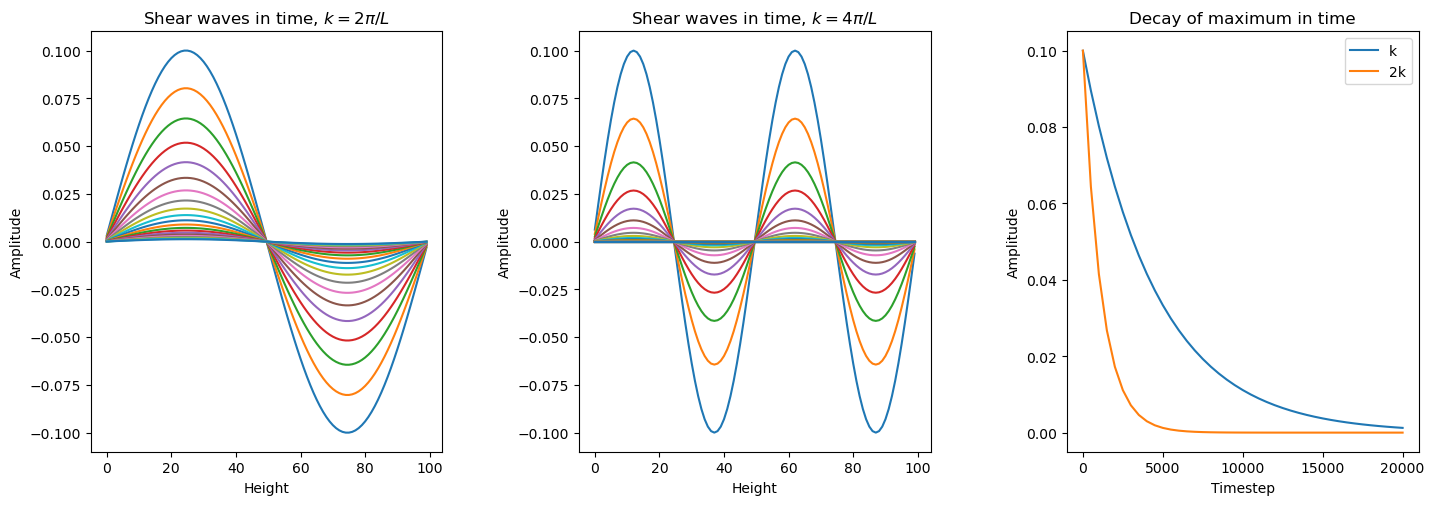

In [8]:
#
fig, (ax1, ax2, ax3) = plt.subplots(1,3,width_ratios=[1./3.,1./3.,1./3.])
fig.tight_layout(pad=1.1)
fig.set_figwidth(15)
# Initialise populations
kx = 2*np.pi/NX  # Wavenumbers
ky = 2*np.pi/NY  #
u1 = np.array([u_max*np.sin(ky*Y.T),np.zeros((NX,NY))])
u2 = np.array([u_max*np.sin(2*ky*Y.T),np.zeros((NX,NY))])
rhog = np.ones((NX,NY))
g = equilibrium(rhog,u1)
rhof = np.ones((NX,NY))
f = equilibrium(rho,u2)
#
amp1=np.array(np.max(u1[0,NX//2,NY//4]))
amp2=np.array(np.max(u2[0,NX//2,NY//8]))
#
T = [0]
ax1.plot(u1[0,NX//2,:])
ax1.set_xlabel('Height')
ax1.set_ylabel('Amplitude')
ax1.set_title(r'Shear waves in time, $k=2\pi/L$')
ax2.plot(u2[0,NX//2,:])
ax2.set_xlabel('Height')
ax2.set_ylabel('Amplitude')
ax2.set_title(r'Shear waves in time, $k=4\pi/L$')
for n in np.arange(1,NSTEPS+1):
    g = Stream(g)
    g = Collide(g)
    f = Stream(f)
    f = Collide(f)
    if n%500==0:
        rhof = np.einsum('ijk->jk',f)
        u1 = np.einsum('ai,ixy->axy',c,g)/rhog  
        u2 = np.einsum('ai,ixy->axy',c,f)/rhof  
        ax2.plot(u2[0,NX//2,:])
        amp1=np.append(amp1, np.max(u1[0,NX//2,NY//4]))
        amp2=np.append(amp2, np.max(u2[0,NX//2,NY//8]))
        #
        T.append(n)
    if n%1000==0:
        #Tmeasure=np.append(Tmeasure,np.array(time))
        rhog = np.einsum('ijk->jk',g)
        u1 = np.einsum('ai,ixy->axy',c,g)/rhog  
        ax1.plot(u1[0,NX//2,:])
#

ax3.plot(T, amp1, label='k')
ax3.plot(T, amp2, label='2k')
ax3.set_xlabel('Timestep')
ax3.set_ylabel('Amplitude')
ax3.set_title(r'Decay of maximum in time')
ax3.legend()